# Activity For Week 7 & 8

In [624]:
pip install fuzzywuzzy

Note: you may need to restart the kernel to use updated packages.


In [625]:
# Remove warning coming while run the code snippet

import warnings
warnings.filterwarnings('ignore',category = UserWarning,module = 'openpyxl')

In [626]:
# Importing Pandas packages required for this excercise.

import pandas as pd
import numpy as np
import seaborn as sns
from fuzzywuzzy import process,fuzz
import matplotlib.pylab as plt
import matplotlib.pyplot as pl
sns.set_style("whitegrid")
sns.set_palette("RdBu")

In [627]:
# read candy hierarchy data set

candyData = pd.read_excel("./candyhierarchy2017.xlsx")

In [628]:
# get sample records out of candy dataframe.

candyData.sample(5)

,Internal ID,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,...,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
2367,90298440,No,Female,30,United States,Connecticut,JOY,NaN,JOY,NaN,...,NaN,NaN,Blue and black,NaN,Friday,NaN,1.0,NaN,NaN,"(60, 29)"
1379,90278928,Yes,Male,48,usa,Ohio,JOY,MEH,JOY,NaN,...,NaN,NaN,White and gold,NaN,Friday,NaN,1.0,NaN,NaN,"(73, 33)"
1430,90279189,NaN,Male,61,USA,IN,JOY,DESPAIR,MEH,MEH,...,NaN,NaN,Blue and black,NaN,Friday,NaN,NaN,NaN,1.0,"(87, 80)"
1215,90277694,No,Male,28,united states,NaN,JOY,JOY,JOY,DESPAIR,...,NaN,NaN,White and gold,NaN,Friday,NaN,1.0,NaN,NaN,"(74, 37)"
1078,90277189,No,Female,50,US,Texas,JOY,DESPAIR,JOY,DESPAIR,...,NaN,Reese's Pieces are off-the-charts Joy. I miss ...,White and gold,NaN,Friday,NaN,1.0,NaN,NaN,"(66, 5)"


In [629]:
#get the dimension of candy data file

candyData.shape

(2460, 120)

In [630]:
# check the null or Nan values in the dataset

candyData.isna().sum()

Internal ID                    0
Q1: GOING OUT?               110
Q2: GENDER                    41
Q3: AGE                       84
Q4: COUNTRY                   64
                            ... 
Q12: MEDIA [Daily Dish]     2375
Q12: MEDIA [Science]        1098
Q12: MEDIA [ESPN]           2361
Q12: MEDIA [Yahoo]          2393
Click Coordinates (x, y)     855
Length: 120, dtype: int64

In [634]:
# checking to see if data is duplicate in the dataset

candyData.duplicated().any()

False

In [635]:
candyData.describe()

,Internal ID,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo]
count,2.460000e+03,85.0,1362.0,99.0,67.0
mean,9.028016e+07,1.0,1.0,1.0,1.0
std,7.435532e+03,0.0,0.0,0.0,0.0
min,9.025877e+07,1.0,1.0,1.0,1.0
25%,9.027520e+07,1.0,1.0,1.0,1.0
50%,9.027780e+07,1.0,1.0,1.0,1.0
75%,9.028242e+07,1.0,1.0,1.0,1.0
max,9.031480e+07,1.0,1.0,1.0,1.0


In [636]:
candyData.describe(include = object)

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),...,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,"Click Coordinates (x, y)"
count,2350,2419,2376,2396,2360,1713,1726,1788,1502,1468,...,1703,1713,1755,911,717,386,1716,9,1735,1605
unique,2,4,106,128,511,3,3,3,3,3,...,3,3,3,867,685,385,2,1,2,952
top,No,Male,40,USA,California,JOY,DESPAIR,JOY,DESPAIR,MEH,...,DESPAIR,DESPAIR,JOY,Almond Joy,Trump,nom nom nom!,White and gold,dress (https://survey.ubc.ca/media/assets/user...,Friday,"(77, 24)"
freq,2038,1467,92,699,132,873,1089,1559,793,857,...,1455,1289,1105,10,7,2,1081,9,1091,9


In [644]:
#Column names list for reference

for col in candyData.columns:
    print(col)


Internal ID
Q1: GOING OUT?
Q2: GENDER
Q3: AGE
Q4: COUNTRY
Q5: STATE, PROVINCE, COUNTY, ETC
Q6 | 100 Grand Bar
Q6 | Anonymous brown globs that come in black and orange wrappers	(a.k.a. Mary Janes)
Q6 | Any full-sized candy bar
Q6 | Black Jacks
Q6 | Bonkers (the candy)
Q6 | Bonkers (the board game)
Q6 | Bottle Caps
Q6 | Box'o'Raisins
Q6 | Broken glow stick
Q6 | Butterfinger
Q6 | Cadbury Creme Eggs
Q6 | Candy Corn
Q6 | Candy that is clearly just the stuff given out for free at restaurants
Q6 | Caramellos
Q6 | Cash, or other forms of legal tender
Q6 | Chardonnay
Q6 | Chick-o-Sticks (we don’t know what that is)
Q6 | Chiclets
Q6 | Coffee Crisp
Q6 | Creepy Religious comics/Chick Tracts
Q6 | Dental paraphenalia
Q6 | Dots
Q6 | Dove Bars
Q6 | Fuzzy Peaches
Q6 | Generic Brand Acetaminophen
Q6 | Glow sticks
Q6 | Goo Goo Clusters
Q6 | Good N' Plenty
Q6 | Gum from baseball cards
Q6 | Gummy Bears straight up
Q6 | Hard Candy
Q6 | Healthy Fruit
Q6 | Heath Bar
Q6 | Hershey's Dark Chocolate
Q6 | Hershey’

#### Above cells' conclusion

##### Dataset has a lot of missing values
##### Dataset has no complete duplicates
##### We need to remove some columns not use
##### We need to modify some column datatype
##### We need to rename some column name to avoid confusion

In [647]:
# show columns that hase more 50 % nan value

for i in range(len(candyData.isnull().sum())):
    if candyData.isna().sum()[i] > 1229 :
        print(f"Column {candyData.isna().sum().index[i]} contains {candyData.isna().sum()[i]} nan value\n")

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/3592699985.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if candyData.isna().sum()[i] > 1229 :


Column Q7: JOY OTHER contains 1549 nan value

Column Q8: DESPAIR OTHER contains 1743 nan value

Column Q9: OTHER COMMENTS contains 2074 nan value

Column Unnamed: 113 contains 2451 nan value

Column Q12: MEDIA [Daily Dish] contains 2375 nan value

Column Q12: MEDIA [ESPN] contains 2361 nan value

Column Q12: MEDIA [Yahoo] contains 2393 nan value



/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/3592699985.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Column {candyData.isna().sum().index[i]} contains {candyData.isna().sum()[i]} nan value\n")


In [648]:
# drop columns we not used

candyData.drop(columns = ["Internal ID", "Unnamed: 113", "Click Coordinates (x, y)"], inplace = True)

In [649]:
# drop columns that contain more than 50 % nan value

candyData.drop(columns=["Q7: JOY OTHER", "Q8: DESPAIR OTHER", "Q9: OTHER COMMENTS"],inplace= True)

In [650]:
# handle columns name

# 1- create dictionary key is old name and value is new name
newNames = {"Q1: GOING OUT?" :"going out", "Q2: GENDER": "gender", "Q3: AGE": "age", "Q4: COUNTRY": "country",
            "Q10: DRESS" : "dress", "Q12: MEDIA [Science]":"Science","Q11: DAY": "day", "Q12: MEDIA [Daily Dish]":"Daily Dish",
            "Q12: MEDIA [ESPN]":"ESPN", "Q12: MEDIA [Yahoo]":"Yahoo"}

# 2- rename columns
candyData.rename(columns = newNames, inplace= True)

In [655]:
# show unique values

candyData["going out"].unique()

array([nan, 'No', 'Yes'], dtype=object)

In [657]:
# Survery respondents intending to 'GO OUT' Trick-or-Treating for Halloween.

i= {'Going Out': ['No','Yes'], 'Count': [2008,298]}
I= pd.DataFrame.from_dict(i)
I['Percentage']= round((I['Count'] / I['Count'].sum()) * 100,2)
I

,Going Out,Count,Percentage
0,No,2008,87.08
1,Yes,298,12.92


<Axes: xlabel='Going Out'>

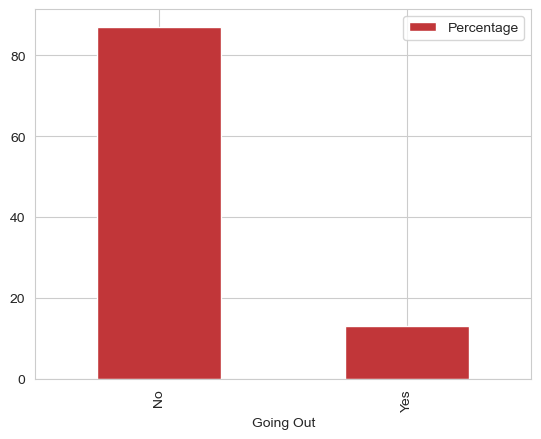

In [659]:
# let's bar chart it to see how it looks like in there

I.plot(kind='bar', x='Going Out', y='Percentage')

#### That's a really high number of respondents that don't intend to Trick-or-Treat for Halloween. So using the data to dig further...

In [662]:
gender = candyData[(candyData.iloc[:, 0] == "No")]
a= pd.DataFrame(gender['gender'].value_counts().sort_index())
a['Percentage']= round(pd.DataFrame(gender['gender'].value_counts(normalize=True)*100).sort_index(),2)

a

,count,Percentage
gender,,
Female,710,35.06
I'd rather not say,69,3.41
Male,1221,60.30
Other,25,1.23


#### We know that Trick-or-Treating is typically for ages 17 and under, and reviewing the data we can see that 99% of the 'NO' by respondents that have reported their age as 18+.

In [665]:
# see number of missing values 

candyData["going out"].isna().sum()

110

In [667]:
# create function that visualized categorical column using pie plot

def pie_plot(column_name, explodeIndex = None):
    """
    1) input : column name, column data type must be object or categorical
    2) explodeIndex, is the index i need to explode it 
    2) output : circle chart that shows size of each unique values and percentage 
    """
    # Create explode list with zeros of size equal to the number of unique values
    explodeList = [0] * candyData[column_name].nunique()
    
    # Check and set explodeIndex value 
    if explodeIndex is not None:
        explodeList[explodeIndex] = 0.1
    
    # Create pie plot
    plt.pie(candyData[column_name].value_counts(), labels = candyData[column_name].value_counts().index, shadow = True, autopct = "%1.1f%%",  explode = explodeList)
    plt.show()

In [669]:
# fill nan value with maybe (yse,no)

candyData["going out"].fillna("MayBe",inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/2909596638.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["going out"].fillna("MayBe",inplace = True)


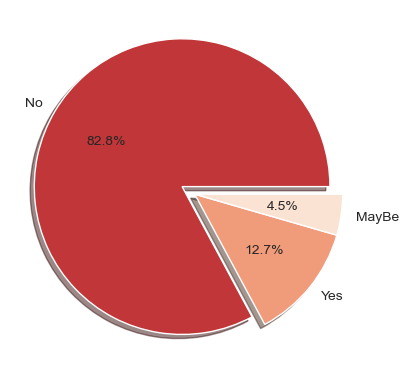

In [671]:
# visualized going out column using pie plot function i create it in cell 15

pie_plot(column_name = "going out", explodeIndex = 0)

##### Most people are not going out by seeing the trend above

## Cleaning Gender Data

In [675]:
# see number of missing values 

candyData["gender"].isna().sum()

41

In [677]:
# fill missing values 

candyData["gender"].fillna("Other", inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/2581853504.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["gender"].fillna("Other", inplace = True)


In [679]:
# replace Other with I'd rather not say

candyData["gender"].replace("I'd rather not say", "Other", inplace = True)

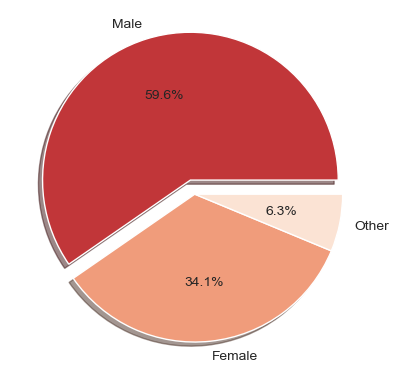

In [681]:
# visualized gender column using pie plot function i create it in cell 15

pie_plot(column_name = "gender", explodeIndex = 0)

##### male is the most common gender here after the analysis.

In [684]:
# create function that visualized numeric columns using box plot

def box_plot(x_axis = None, y_axis = None):
    """
    input : x_axis, y_axis and hue column, column data type must be numeric in y_axis
    output : box plot to see distribution of column values such as min,max,mean,medien,std
    """
    sns.boxplot(x = x_axis, y = y_axis, data = candyData)
    plt.xlabel(x_axis)
    plt.show()

## Cleaning Age Data

In [687]:
# show unique values

candyData["age"].unique()

array([nan, 44, 49, 40, 23, 53, 33, 43, 56, 64, 37, 59, 48, 54, 36, 45,
       25, 34, 35, 38, 58, 50, 47, 16, 52, 63, 65, 41, 27, 31, 61, 46, 42,
       62, 29, 39, 32, 28, 69, 67, 30, 22, 26, 51, 70, 24, 18, 19,
       'Old enough', 57, 60, 66, 12, 'Many', 55, 72, '?', 21, 11, 'no', 9,
       68, 20, 6, 10, 71, 90, 13, '45-55', 312, 99, 7, 'hahahahaha', 88,
       39.4, 74, 102, 'older than dirt', 17, 15, 8, 75, '5u', 'Enough',
       'See question 2', '24-50', 14, 'Over 50', 100, 76, 1000,
       'sixty-nine', '46 Halloweens.', 'ancient', 77, 'OLD', 'old', 73,
       70.5, 1, 'MY NAME JEFF', 4, '59 on the day after Halloween',
       'old enough', 'your mom',
       'I can remember when Java was a cool new language', '60+'],
      dtype=object)

In [689]:
# convert column data type to numiric and replace non-digits to NAN value

candyData['age'] = pd.to_numeric(candyData["age"], errors = "coerce")

In [691]:
# show how many nan value 

candyData["age"].isna().sum()

108

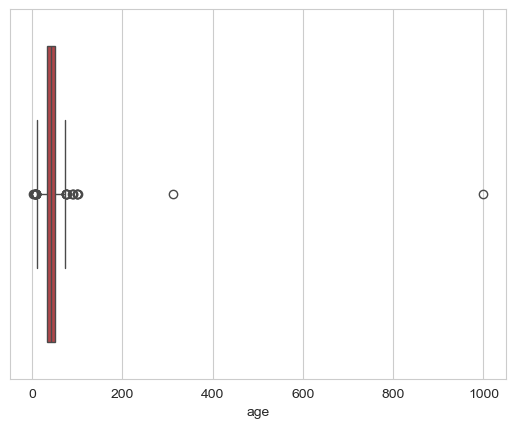

In [693]:
# show summary statistic

box_plot(x_axis = "age") # box plot function i create it in cell 16

##### age column has lot of outliers that need to fixed

In [696]:
# fixed outlier

Q1, Q3 = candyData["age"].quantile(0.25), candyData["age"].quantile(0.75)

IQR = Q3 - Q1

Upper = Q3 + (1.5 * IQR)
Lower = Q1 - (1.5 * IQR)

# replace out of range with nan value
candyData.loc[(candyData["age"] > Upper) | (candyData["age"] < Lower), "age"] = np.nan

In [698]:
# fill nan value with median

median = candyData["age"].median()
candyData["age"].fillna(median, inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/3545944901.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["age"].fillna(median, inplace = True)


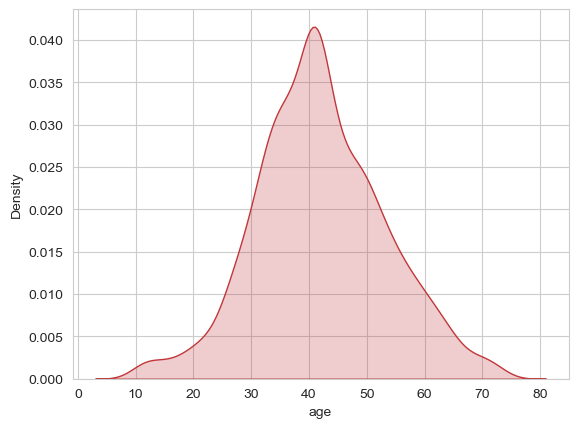

In [700]:
# see distribution

sns.kdeplot(x = "age", data = candyData, fill = True)
plt.show()

###### Most people who did the survey were between 35 and 50

### Cleaning Country Data

In [704]:
# show unique values

candyData["country"].unique()

array([nan, 'USA ', 'USA', 'us', 'usa', 'canada', 'Canada', 'Us', 'US',
       'Murica', 'United States', 'uk', 'United Kingdom', 'united states',
       'Usa', 'United States ', 'United staes',
       'United States of America', 'UAE', 'England', 'UK', 'canada ',
       'Mexico', 'United states', 'u.s.a.', 'USAUSAUSA', 'america', 35,
       'france', 'United States of America ', 'U.S.A.', 'finland',
       'unhinged states', 'Canada ', 'united states of america',
       'US of A', 'Unites States', 'The United States', 'North Carolina ',
       'Unied States', 'Netherlands', 'germany', 'Europe', 'Earth', 'U S',
       'u.s.', 'U.K. ', 'Costa Rica', 'The United States of America',
       'unite states', 'U.S.', 46, 'cascadia', 'Australia',
       'insanity lately', 'Greece', 'USA? Hard to tell anymore..',
       "'merica", 'usas', 'Pittsburgh', 45, 'United State', 32, 'France',
       'australia', 'A', 'Can', 'Canae', 'New York', 'Trumpistan',
       'Ireland', 'United Sates', 'Korea', 

In [706]:
# fixed some errors

# 1- convert all value to lower case
candyData["country"] = candyData["country"].str.lower()

# 2- remove extra spaces 
candyData["country"] = candyData["country"].str.strip()

In [708]:
# show how many nan value 

candyData["country"].isna().sum() 

69

In [710]:
# fill nan value

candyData["country"].fillna("Other", inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/2886944220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["country"].fillna("Other", inplace = True)


In [712]:
# show again unique value

candyData["country"].unique()

array(['Other', 'usa', 'us', 'canada', 'murica', 'united states', 'uk',
       'united kingdom', 'united staes', 'united states of america',
       'uae', 'england', 'mexico', 'u.s.a.', 'usausausa', 'america',
       'france', 'finland', 'unhinged states', 'us of a', 'unites states',
       'the united states', 'north carolina', 'unied states',
       'netherlands', 'germany', 'europe', 'earth', 'u s', 'u.s.', 'u.k.',
       'costa rica', 'the united states of america', 'unite states',
       'cascadia', 'australia', 'insanity lately', 'greece',
       'usa? hard to tell anymore..', "'merica", 'usas', 'pittsburgh',
       'united state', 'a', 'can', 'canae', 'new york', 'trumpistan',
       'ireland', 'united sates', 'korea', 'california', 'japan',
       'south africa',
       'i pretend to be from canada, but i am really from the united states.',
       'iceland', 'canada`', 'scotland', 'denmark', 'united stated',
       'switzerland', 'ahem....amerca', 'ud', 'south korea', 'new jers

In [714]:
countries = pd.Series(['usa', 'united states of america','america','united kingdom england', 'hong kong', 'china', 'sweden', 'spain',
                       'ireland', 'taiwan', 'singapore', 'netherlands',
                       'indonesia', 'south korea', 'switzerland', 'denmark', 'scotland', 'canada', 'iceland', 'south africa',
                       'japan', 'greece', 'costa rica', 'germany', 'finland', 'france', 'mexico'])

for country in countries:
    matches = process.extract(country, candyData['country'], limit = candyData.shape[0])
    for potential_match in matches:
        if potential_match[1] >= 80:
            candyData.loc[candyData['country'] == potential_match[0], 'country'] = country

In [715]:
# show unique values again

candyData["country"].unique()

array(['Other', 'usa', 'canada', 'murica', 'america', 'uk', 'uae',
       'united kingdom england', 'mexico', 'u.s.a.', 'france', 'finland',
       'north carolina', 'netherlands', 'germany', 'europe', 'earth',
       'u.k.', 'costa rica', 'cascadia', 'australia', 'insanity lately',
       'greece', 'usa? hard to tell anymore..', 'pittsburgh', 'canae',
       'new york', 'trumpistan', 'iceland', 'south korea', 'california',
       'japan', 'south africa', 'scotland', 'denmark', 'switzerland',
       'ud', 'new jersey', 'indonesia', 'endland', 'atlantis', 'murrika',
       'alaska', 'soviet canuckistan', 'singapore', 'china', 'taiwan',
       'hong kong', 'spain', 'sweden', 'narnia', 'u s a',
       'subscribe to dm4uz3 on youtube', "i don't know anymore",
       'fear and loathing'], dtype=object)

In [716]:
mapping = {'murica':'usa', 'united states of america':'usa','america':'usa', 'u.s.a.':'usa',
'north carolina':'usa', 'usa? hard to tell anymore..':'usa', 'pittsburgh':'usa', 'new york':'usa', 'trumpistan':'usa',
          'california':'usa', 'ud':'usa', 'new jersey':'usa', 'endland':'uk', 'soviet canuckistan':'canada',
           'u s a':'usa', 'united kingdom england':'uk', 'u.k.':'uk', 'cascadia':'usa'}
candyData['country'] = candyData['country'].replace(mapping)

In [717]:
# show unique values again

candyData["country"].unique()

array(['Other', 'usa', 'canada', 'uk', 'uae', 'mexico', 'france',
       'finland', 'netherlands', 'germany', 'europe', 'earth',
       'costa rica', 'australia', 'insanity lately', 'greece', 'canae',
       'iceland', 'south korea', 'japan', 'south africa', 'scotland',
       'denmark', 'switzerland', 'indonesia', 'atlantis', 'murrika',
       'alaska', 'singapore', 'china', 'taiwan', 'hong kong', 'spain',
       'sweden', 'narnia', 'subscribe to dm4uz3 on youtube',
       "i don't know anymore", 'fear and loathing'], dtype=object)

In [718]:
candyData.country[~candyData['country'].isin(['usa', 'uk','canada'])] = 'other'

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/3281192361.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  candyData.country[~candyData['country'].isin(['usa', 'uk','canada'])] = 'other'
/var/folders/18/ygzmjvj90m72g8_1d

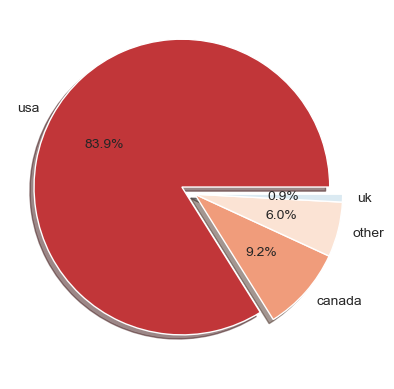

In [719]:
# visualized country column

pie_plot(column_name = "country", explodeIndex = 0)

###### Most people from USA and Canada

## Cleaning Dress Data

In [722]:
# show unique values

candyData["dress"].unique()

array([nan, 'White and gold', 'Blue and black'], dtype=object)

In [723]:
# see number of missing values 

candyData["dress"].isna().sum()

744

In [724]:
# fill nan value

candyData["dress"].fillna("Other colors", inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/1723580999.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["dress"].fillna("Other colors", inplace = True)


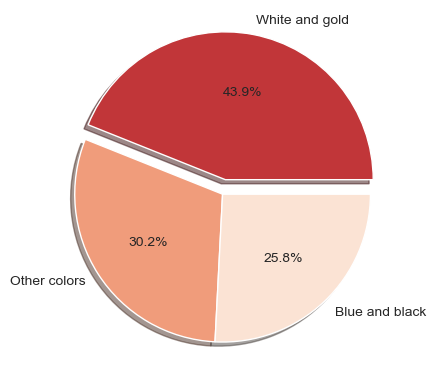

In [725]:
# visualized dress column

pie_plot(column_name = "dress", explodeIndex = 0)

###### yaahhh i owuld say most people like dress white and gold and me personally not

## Cleaning Day Data

In [728]:
# show unique values

candyData["day"].unique()

array([nan, 'Sunday', 'Friday'], dtype=object)

In [729]:
# see number of missing values 

candyData["day"].isna().sum()

725

In [730]:
# fill nan value 

candyData["day"].fillna("Other Day", inplace = True)  

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/148572846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["day"].fillna("Other Day", inplace = True)


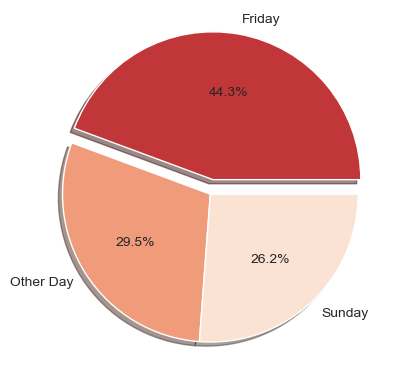

In [731]:
# visualized day column

pie_plot(column_name = "day", explodeIndex = 0)

##### Most people preferred friday and Me too.

In [733]:
# create sub dataframe media

media = candyData[candyData.columns[-4:]]
media

,Daily Dish,Science,ESPN,Yahoo
0,NaN,NaN,NaN,NaN
1,NaN,1.0,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,1.0,NaN,NaN
4,NaN,1.0,NaN,NaN
...,...,...,...,...
2455,NaN,NaN,NaN,NaN
2456,NaN,1.0,NaN,NaN
2457,NaN,1.0,NaN,NaN
2458,NaN,NaN,NaN,NaN


In [734]:
# fill nan value with No 

media = media.fillna("NO")

In [735]:
# Show most website checked out

# 1- craate list of media category
media_category = ["Science", "ESPN", "Daily Dish", "Yahoo"]

# 2- create dictionary key is media category and value is number of ones
media_used = {}

# 3- loop of list madie to get number of ones
for category in media_category:
    media_used[category] = len(candyData[candyData[category] == 1.0])
    
# 4- calculation number of No answer 
media_used["No answer"] = candyData.shape[0] - sum(media_used.values())

# 5- sorte media_used by values
media_used = dict(sorted(media_used.items(), key = lambda item : item[1] ,reverse = True))

# 6- get all keys in media_used
keys = list(media_used.keys())

# 7- get all values in media_used
values = list(media_used.values())

In [736]:
# create media column and fill with nan value

candyData["media"] = np.nan

In [737]:
# fill nan value using media used dictionary

for key,value in media_used.items():
    candyData["media"].fillna(key,limit = value, inplace = True)

/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/486186341.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  candyData["media"].fillna(key,limit = value, inplace = True)
/var/folders/18/ygzmjvj90m72g8_1d1sfk1b80000gn/T/ipykernel_72871/486186341.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Science' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  candyData["media"].fillna(key,limi

In [738]:
# create function to visualized categorical column using count plot

def count_plot(x_axis = None, y_axis = None, hue = None, rotation = 0, top = None):
    """
    1) input : x_axis, column name, data type must be object or categorical
    3) output : cout plot using seaborn modules, unique values in x-axis and frequency in y-axis
    4) use bar_label to show frequency of each unique values above each column in graph
    5) top parameter i use it to specify indexes i want to see it
    """
    if x_axis: # if we neet to visualized in x-axis
        order = candyData[x_axis].value_counts().iloc[:top].index
        
    else : # if we neet to visualized in y-axis
        order = candyData[y_axis].value_counts().iloc[:top].index
        
    graph = sns.countplot(x = x_axis, y = y_axis, data = candyData, hue = hue, order = order)
    for container in graph.containers:
        graph.bar_label(container)
        
        
    plt.xticks(rotation = rotation)
    plt.show()

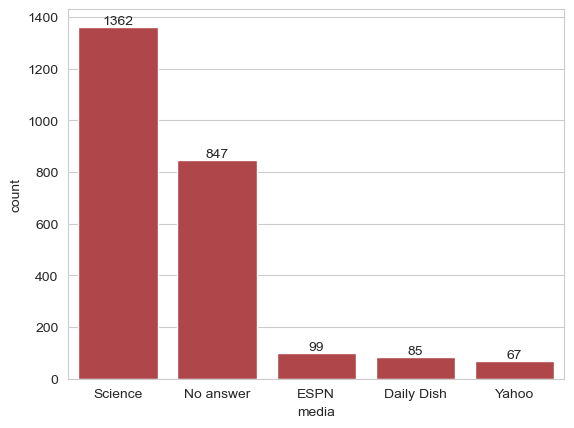

In [739]:
# visualized media column

count_plot(x_axis = "media")

#### Science is the most website checked out

In [754]:
# 1- create list of Question columns 
Question = [candy for candy in candyData.columns if 'Q6' in str(candy)]

# 2- create dataframe call candy
candy = pd.DataFrame(candyData[Question])

In [763]:
# show sample of dataframe

candy.sample(5)

,Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),Q6 | Bonkers (the board game),Q6 | Bottle Caps,Q6 | Box'o'Raisins,Q6 | Broken glow stick,Q6 | Butterfinger,...,Q6 | Three Musketeers,Q6 | Tolberone something or other,Q6 | Trail Mix,Q6 | Twix,"Q6 | Vials of pure high fructose corn syrup, for main-lining into your vein",Q6 | Vicodin,Q6 | Whatchamacallit Bars,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties
117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
749,MEH,DESPAIR,JOY,MEH,MEH,MEH,MEH,DESPAIR,DESPAIR,MEH,...,JOY,JOY,DESPAIR,JOY,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH
1516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1098,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,JOY,...,DESPAIR,MEH,DESPAIR,JOY,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,JOY


In [765]:
# see dimensions 

candy.shape

(2460, 103)

In [768]:
# show how many nan value in each column

candy.isna().sum()

Q6 | 100 Grand Bar                                                                        747
Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes)    734
Q6 | Any full-sized candy bar                                                             672
Q6 | Black Jacks                                                                          958
Q6 | Bonkers (the candy)                                                                  992
                                                                                         ... 
Q6 | Vicodin                                                                              789
Q6 | Whatchamacallit Bars                                                                 823
Q6 | White Bread                                                                          757
Q6 | Whole Wheat anything                                                                 747
Q6 | York Peppermint Patties                                

#### From above

##### We need to fill nan value with other value
##### We need to rename column name to avoid confusion

In [771]:
# fill nan value 

candy.fillna("unknown", inplace = True)

In [773]:
# handle candy columns name

# 1- create  dictionary key is old name and value is new name of each column
names = {}

# 2- loop over columns to fixed name and store old and new name in names
for col in candy.columns:
    names[col] = col.strip("Q6 | ")
    
# 3- rename columns
candy.rename(columns = names, inplace= True)

In [775]:
candy.sample(3)

,100 Grand Bar,Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Any full-sized candy bar,Black Jacks,Bonkers (the candy),Bonkers (the board game),Bottle Caps,Box'o'Raisins,Broken glow stick,Butterfinger,...,Three Musketeers,Tolberone something or other,Trail Mix,Twix,"Vials of pure high fructose corn syrup, for main-lining into your vein",Vicodin,Whatchamacallit Bars,White Bread,Whole Wheat anything,York Peppermint Patties
196,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,MEH,...,MEH,JOY,unknown,unknown,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR
1449,JOY,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,...,JOY,MEH,MEH,JOY,DESPAIR,JOY,JOY,DESPAIR,MEH,JOY
1822,MEH,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,...,DESPAIR,JOY,MEH,JOY,DESPAIR,MEH,MEH,DESPAIR,MEH,DESPAIR


In [777]:
# handle candy columns

def visualizing(reversed):
    # 1- create create dictionary key is Question and value is number of ones
    candy_score = {}

    # 2- loop over columns to get number of ones of each column
    for column in candy.columns:
        candy_score[column] = len(candy[candy[column] == "JOY"])

    # 3- sorte candy_score by values
    candy_score = dict(sorted(candy_score.items(), key = lambda item : item[1] ,reverse = reversed))

    # 4- get all keys in candy_score
    keys = list(candy_score.keys())

    # 5- get all values in candy_score
    values = list(candy_score.values())
    
    # 6- visualizing columns
    sns.barplot(y = keys[:5], x = values[:5])
    plt.title("Candy distirbution")
    plt.xlabel("Count"); plt.ylabel("Candy")
    plt.xticks(rotation = 55)
    plt.show()

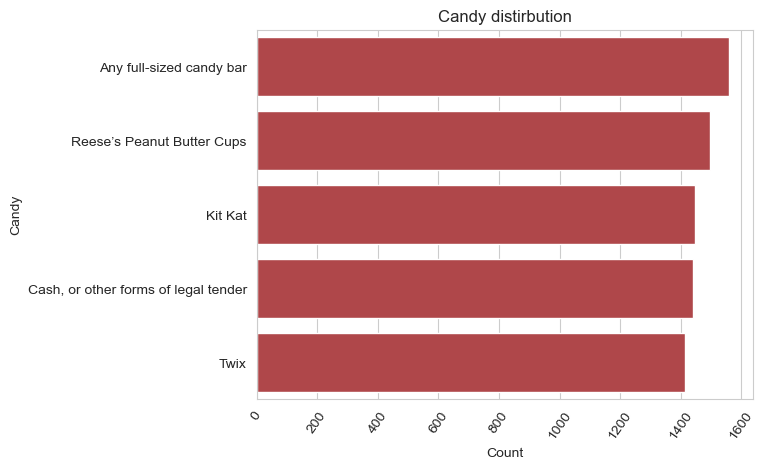

In [779]:
# Top five favorite candy

visualizing(True)

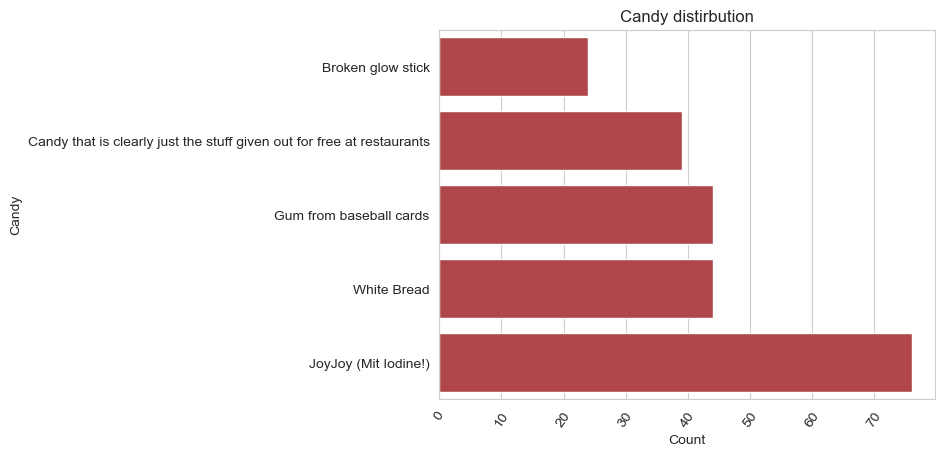

In [781]:
# First five hated candy

visualizing(False)

#### Relationship between categorical columns

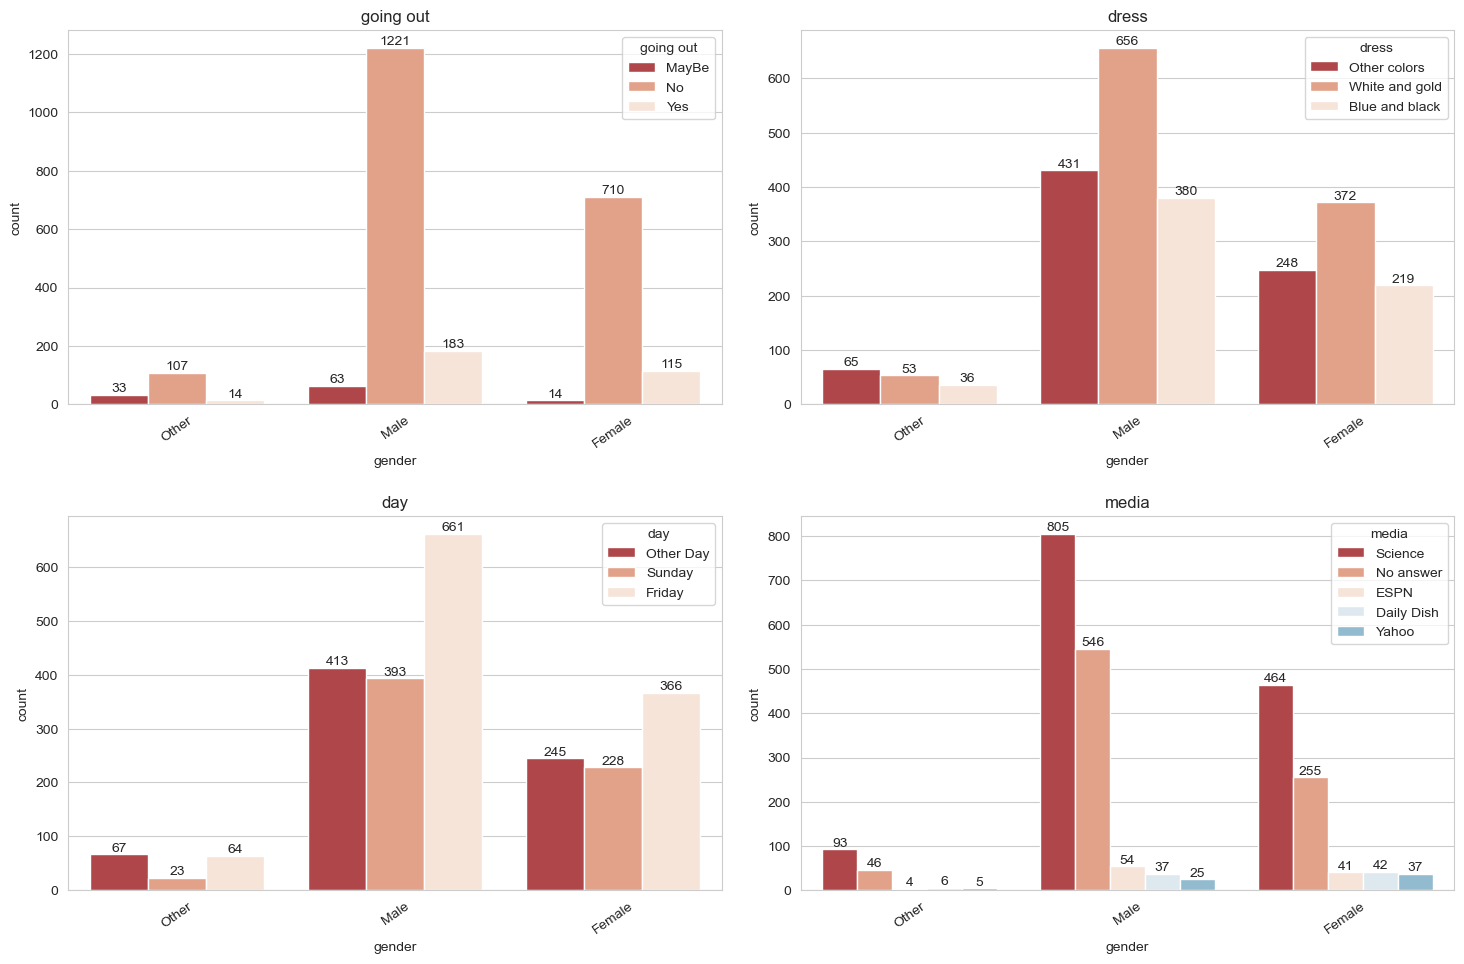

In [784]:
# create list of columns
catColumns = ["going out", "dress", "day", "media"]

# 1- set figure size
plt.figure(figsize=(15, 10))

# 2- loop over objcolumns list to plot columns
for index, col in enumerate(catColumns):
    plt.subplot((len(catColumns) + 1) // 2, 2, index + 1)
    graph = sns.countplot(x = "gender", data = candyData, hue = col)
    for container in graph.containers:
        graph.bar_label(container)
        
    plt.title(col) # set title to each plot
    plt.xticks(rotation = 35)
    
# 3- set layout between two plots
plt.tight_layout(pad = 2)
plt.show()

### Conclusion
##### Reached Results from Questions
##### Most people aren't going out
##### Male is the most common gender
##### Most people who did the survey age between 35 and 50
##### Most countries from USA and Canada
##### Most people like dress white and gold
##### Most people preferred friday
##### Science is the most website checked out
##### Full-sized candy bar is the most loved candy
##### Broken glow stick is the most hated candy